#Machine Learning Pipeline for Sales & Price Forecasting



This project focuses on designing and implementing an end-to-end Machine Learning pipeline on sales and pricing data.

The workflow includes data preprocessing, exploratory data analysis (EDA), feature engineering, regression modeling, hyperparameter tuning, and time series forecasting to analyze trends and improve prediction accuracy.

## 1. Importing Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##2. Loading the Dataset

In [ ]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## 3. Data Preprocessing

In [ ]:
df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


## 4. Exploratory Data Analysis (EDA)

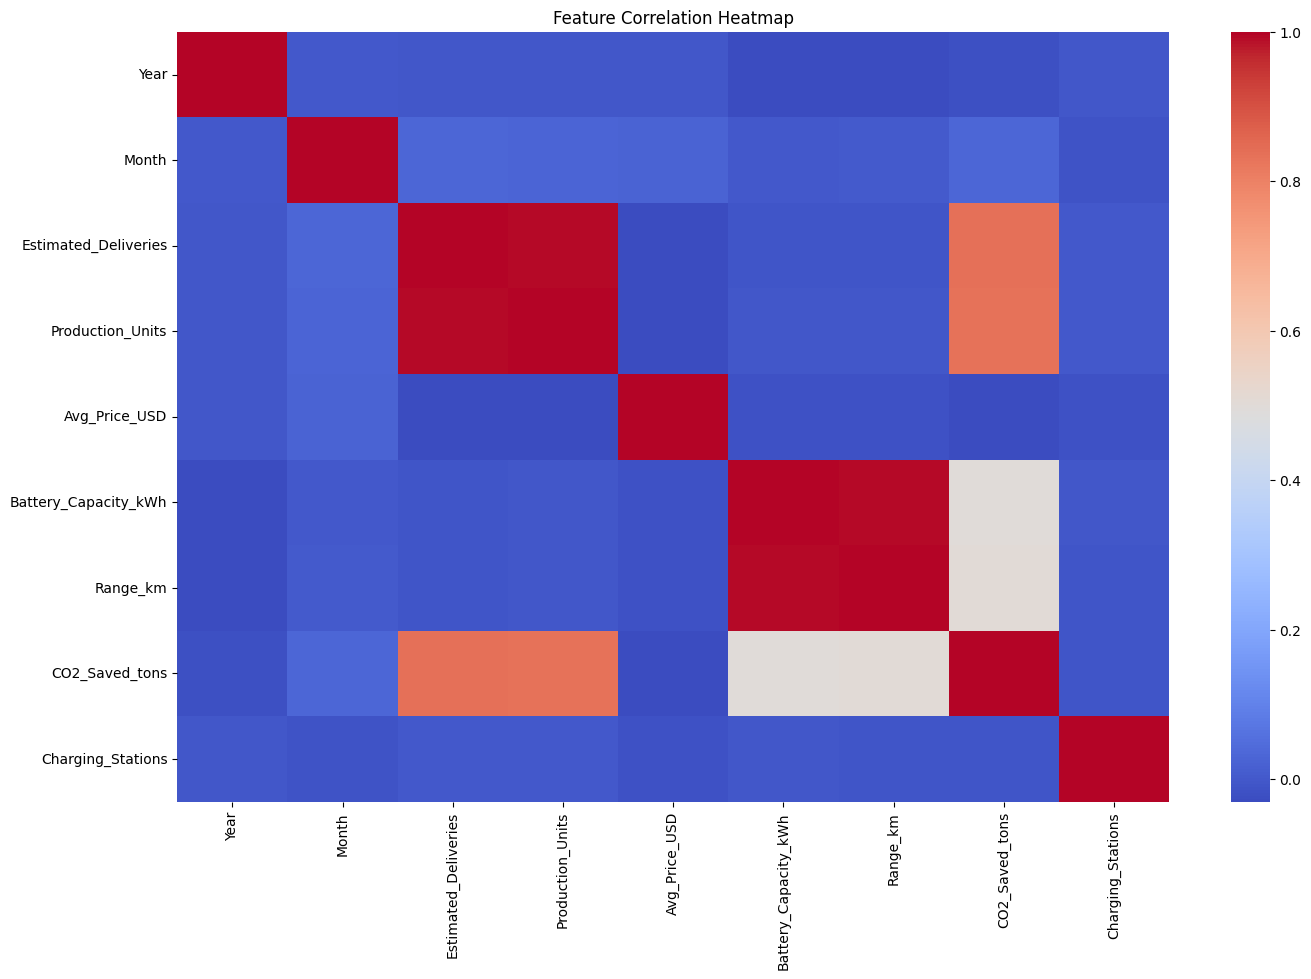

In [ ]:
plt.figure(figsize=(16,10))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm',
    annot=False
)

plt.title("Feature Correlation Heatmap")

plt.show()

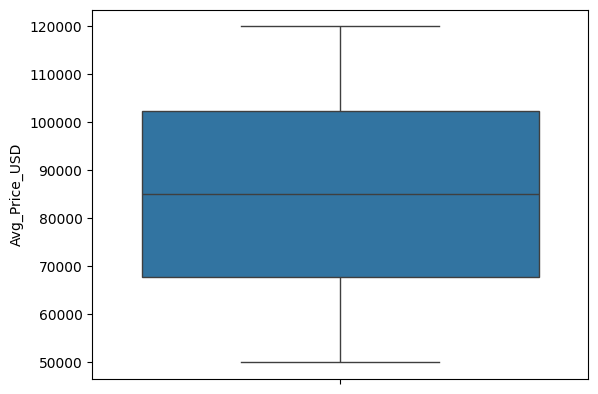

In [ ]:
sns.boxplot(df['Avg_Price_USD'])
plt.show()
q1 = df['Avg_Price_USD'].quantile(0.25)
q3 = df['Avg_Price_USD'].quantile(0.75)

iqr = q3 - q1

df = df[
    (df['Avg_Price_USD'] >= q1 - 1.5*iqr) &
    (df['Avg_Price_USD'] <= q3 + 1.5*iqr)
]

## 5. Feature Engineering

In [ ]:
# Checking categorical columns
df.select_dtypes(include='object').columns

Index(['Region', 'Model', 'Source_Type'], dtype='object')

In [ ]:
print(df.columns)

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')


In [ ]:
# One Hot Encoding
from sklearn.preprocessing import OneHotEncoder
df = pd.get_dummies(
    df,
    columns=['Region', 'Model', 'Source_Type'],
    drop_first=True
)

In [ ]:
# New Features

df['Delivery_Efficiency'] = (
    df['Estimated_Deliveries'] /
    df['Production_Units']
)

## 6. Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('Avg_Price_USD', axis=1)
y = df['Avg_Price_USD']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 7. Model Building

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## 8. Model Evaluation

In [ ]:
def evaluate_model(y_test, pred, model_name):

    print(f"\n{model_name}")

    print("MAE :", mean_absolute_error(y_test, pred))

    print("MSE :", mean_squared_error(y_test, pred))

    print("RMSE :", np.sqrt(mean_squared_error(y_test, pred)))

    print("R2 Score :", r2_score(y_test, pred))

## 9. Hyperparameter Tuning

In [ ]:
evaluate_model(y_test, rf_pred, "Random Forest")


Random Forest
MAE : 643.2649171227444
MSE : 768081.1886986907
RMSE : 876.4024125358685
R2 Score : 0.9979632584219701


In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 300}


In [ ]:
from xgboost import XGBRegressor
xgb = XGBRegressor()
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
print("R2 Score:", r2_score(y_test, pred))

R2 Score: 0.9972977212692102


## 10. Time Series Forecasting

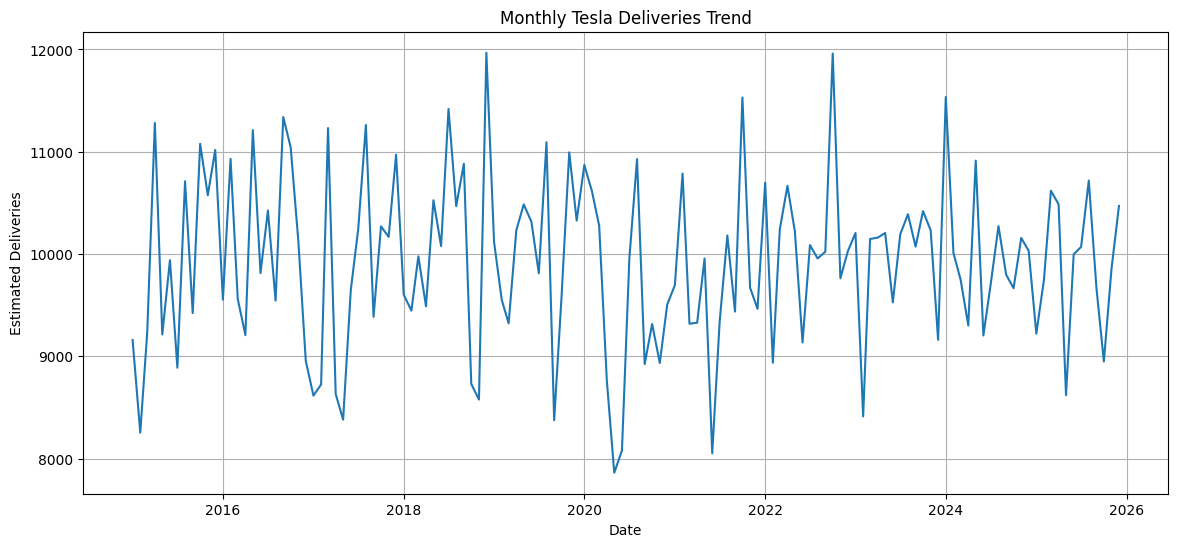

In [ ]:
# Create Date Column

df['Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' +
    df['Month'].astype(str)
)

# Monthly Aggregation

monthly_data = df.groupby('Date')[
    'Estimated_Deliveries'
].mean()

plt.figure(figsize=(14,6))

plt.plot(monthly_data)

plt.title("Monthly Tesla Deliveries Trend")

plt.xlabel("Date")

plt.ylabel("Estimated Deliveries")

plt.grid(True)

plt.show()

In [ ]:
# Setting Date as index
df.set_index('Date', inplace=True)

# Sorting by Date
df = df.sort_index()

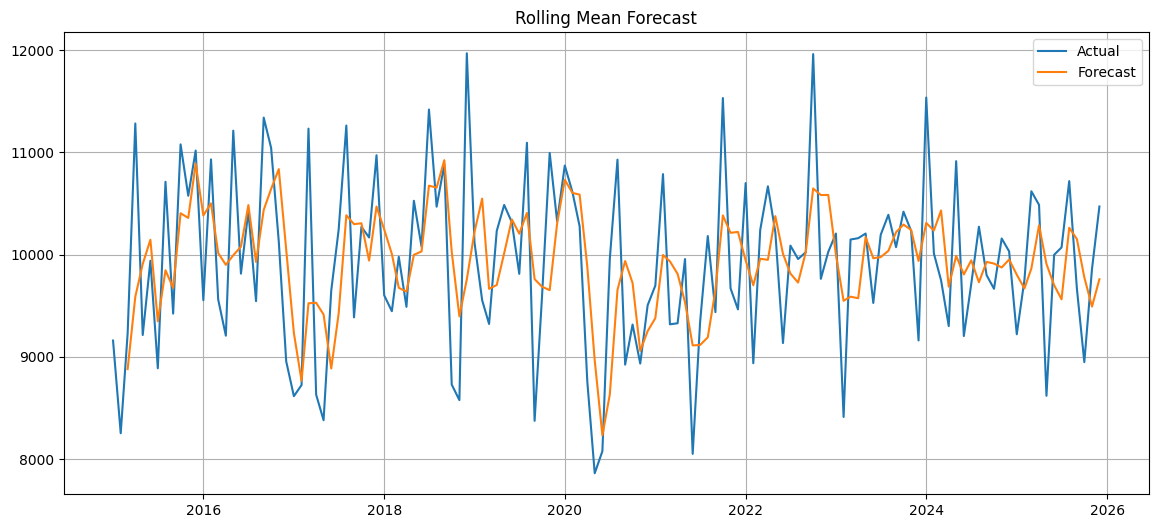

In [ ]:
#Rolling Forecast Graph
forecast = monthly_data.rolling(window=3).mean()

plt.figure(figsize=(14,6))

plt.plot(monthly_data, label='Actual')

plt.plot(forecast, label='Forecast')

plt.title("Rolling Mean Forecast")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# Forecast Values
forecast.tail()

,Estimated_Deliveries
Date,
2025-08-01,10261.633333
2025-09-01,10151.400000
2025-10-01,9777.633333
2025-11-01,9490.783333
2025-12-01,9758.350000


## 11. Conclusion

The project successfully implemented an end-to-end ML pipeline for sales and price forecasting. Different preprocessing, feature engineering, and regression techniques were applied to improve prediction performance and analyze future trends.